In [24]:
from astropy.io import fits, ascii
from astropy.table import Table, vstack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import LogStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from mpl_scatter_density import ScatterDensityArtist
import matplotlib.ticker as ticker
plt.rcParams.update({
    "font.family": "serif",  
    "text.usetex": True,
    'axes.labelsize':18,
    'xtick.labelsize':18,
    'ytick.labelsize':18})

In [3]:
data=fits.open('ms_wd_original_data_from_Gaia_query.fits',memmap=True) 

data=Table(data[1].data).to_pandas()

data.dropna(inplace=True)

bprp=data['bp_rp'].values
G_abs=data['phot_g_mean_mag'].values + 5 + 5*np.log10(data['parallax'].values/1000)

target=pd.read_csv("ms_wd_topcat_selected_targets.csv")

bprp_target=target['bp_rp'].values
G_abs_target=target['phot_g_mean_mag'].values + 5 + 5*np.log10(target['parallax'].values/1000)

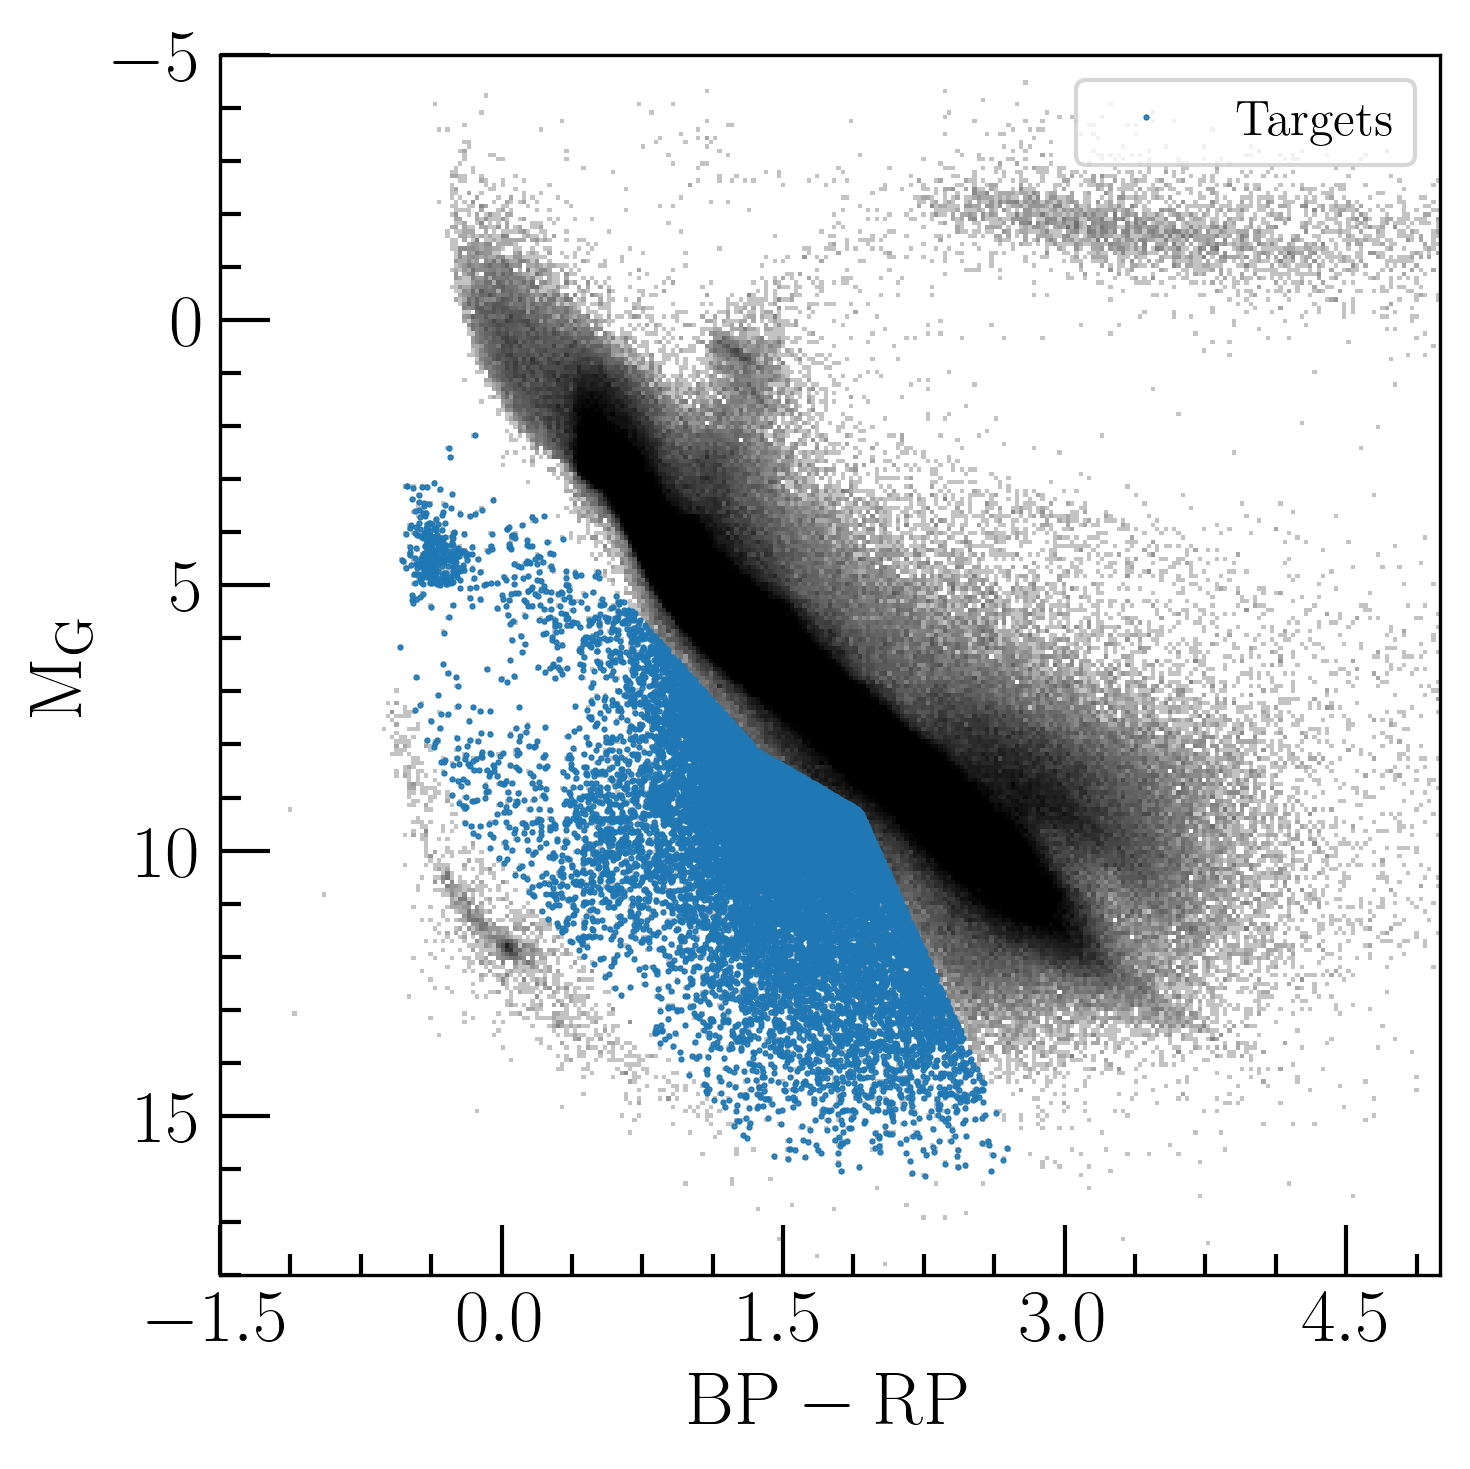

In [34]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300, subplot_kw={'projection': 'scatter_density'})

ax.set_facecolor("white")


norm = ImageNormalize(vmin=0., vmax=100, stretch=LogStretch())


density = ax.scatter_density(bprp, G_abs, norm=norm, cmap="Greys", downres_factor=1)


ax.plot(bprp_target, G_abs_target,'o', ms=0.5,label='Targets')



ax.set_xlabel(r"$B_{p} - R_{p}$ \textbf{(mag)}")  
ax.set_ylabel(r"$M_{G}$ \textbf{(mag)}")


ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))



plt.minorticks_on()
plt.tick_params('both', length=12, width=1., which='major', direction='in')	
plt.tick_params('both', length=5, width=1, which='minor', direction='in')

ax.set_ylim([18,-5])
ax.set_xlim([-1.5,5])
ax.set_xlabel(r'$\rm BP-RP$')
ax.set_ylabel(r'$\rm M_G$')

ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('CMD_targets_ms_wd.pdf',format='pdf')